## Imports, installs, initial set up

In [ ]:
import numpy as np 
import pandas as pd

import scanpy as sc 
import anndata as ann 

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, confusion_matrix, ConfusionMatrixDisplay
import umap 

import os

import matplotlib.pyplot as plt
import seaborn as sns
# Hacky within notebook installation of igraph 
%pip install igraph
%pip install leidenalg

######## writing this here so we do not lose track
np.random.seed(17)

/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Defining Functions
All functions used in this notebook are defined in the code block below.

In [ ]:
# DEFINING FUNCTIONS HERE
# Create a function that splits the anndatas into 3 anndatas based on the integration method 
def split_adata(adata):
    # Get the integration method from the obs attribute
    integration_method = adata.obs['integration_method'].values 
    
    # Subset the adata based on the integration method
    adata_uce = adata[integration_method == 'uce']
    adata_scgpt = adata[integration_method == 'scgpt']
    adata_geneformer = adata[integration_method == 'geneformer']
    
    return adata_uce, adata_scgpt, adata_geneformer

# Create a function that counts the number of cells in each celltype
def get_counts(adata):
    # Get the counts of celltypes in the adata object
    counts = adata.obs['celltype'].value_counts()
    
    # Return the counts as a dataframe
    df = pd.DataFrame(counts)
    
    return df

# Create a function that creates a confusion matrix of the leiden labels and the batch labels
def get_confusion_matrix(adata):
    # Perform leiden clustering using the embedding information 
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_emb_reduced')
    sc.tl.leiden(adata, resolution=1.0) # originally 1.0
    
    # Get the celltype and batch labels
    batch_labels = adata.obs['batch'].values
    
    # Get the leiden labels
    leiden_labels = adata.obs['leiden'].values
    
    conf_matrix_batch = confusion_matrix(batch_labels, leiden_labels)# batch is true, leiden is predicted
    
    return conf_matrix_batch  

# Create a function that computes the ARI and AMI for batch correction and cell type clustering
# also finds the cell type that has been downsampled or ablated 
def get_metrics(adata):
    # Perform leiden clustering using the embedding information 
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_emb_reduced')
    sc.tl.leiden(adata, resolution=1.0) # originally 1.0
    
    # Get the celltype and batch labels
    celltype_labels = adata.obs['celltype'].values
    batch_labels = adata.obs['batch'].values
    
    # Get the leiden labels
    leiden_labels = adata.obs['leiden'].values
    
    # Calculate the ARI and AMI for cell-type conservation
    ari_celltype = adjusted_rand_score(celltype_labels, leiden_labels)
    ami_celltype = adjusted_mutual_info_score(celltype_labels, leiden_labels)
    
    # Calculate the ARI and AMI for batch-correction
    ari_batch = 1 - adjusted_rand_score(batch_labels, leiden_labels)
    ami_batch = 1 - adjusted_mutual_info_score(batch_labels, leiden_labels)
    
    # Find the cell type that hhas been downsampled or ablated
    counts = get_counts(adata)
    low_counts = counts[counts['count'] < 400]
    if low_counts.empty:
        reduced_celltype = "NA"
    else:
        reduced_celltype = low_counts.index[0]
    
    # Create a dictionary to store the metrics
    metrics = {
        'ari_celltype': ari_celltype,
        'ami_celltype': ami_celltype,
        'ari_batch': ari_batch,
        'ami_batch': ami_batch,
        'reduced_celltype': reduced_celltype
    }
    
    return metrics

# Create a function to convert the metrics to a dataframe
def metrics_to_df(metrics, integration_method, experiment):
    # Create a dataframe from the metrics
    df = pd.DataFrame(metrics)
    
    # Add the integration method to the dataframe
    df['integration_method'] = integration_method
    
    # Add the experiment type to the data frame
    df['experiment_type'] = experiment
    
    # Want to add the celltype being downsampled or ablated
    
    return df

In [ ]:
# Define working directory - adjust to where your data is
os.chdir('../../../../snakemake_outfiles/apr16_real_results/andoizum/scratch/results/control/integrated_results/')
# Start by reading the files from the results dir
results_files = os.listdir()

# Group files based on control, downsampled and ablated 
control_files = [f for f in results_files if '0_batch_ds' in f]
ds_files = [f for f in results_files if '1_celltypes_0.1_downsample_1_batch_ds' in f]
ablated_files = [f for f in results_files if '1_celltypes_0_downsample_1_batch_ds' in f]

# Separating 2 batch based balanced from hierarchical balanced
# hierarchical balanced is not used in this analysis at this point
control_files_base = [cf for cf in control_files if 'base' in cf]
ds_files_base = [dsf for dsf in ds_files if 'base' in dsf]
ablated_files_base = [af for af in ablated_files if 'base' in af]

# Check how many files we have for each experiment
# len(control_files_base), len(ds_files_base), len(ablated_files_base)

# Randomly sample 45 control files, 45 downsampled files and 45 ablated files
# 45 - because downsampling only has 47 files total
control_files_sample = np.random.choice(control_files_base, 45, replace=False)
ds_files_sample = np.random.choice(ds_files_base, 45, replace=False)
ablated_files_sample = np.random.choice(ablated_files_base, 45, replace=False)

# Load the files into a list of adata objects
control_adata = [sc.read(f) for f in control_files_sample]
ds_adata = [sc.read(f) for f in ds_files_sample]
ablated_adata = [sc.read(f) for f in ablated_files_sample]

# Split the adata objects into 3 adata objects based on the integration method
control_adatas_uce = []
control_adatas_scgpt = []
control_adatas_geneformer = []

ds_adatas_uce = []
ds_adatas_scgpt = []
ds_adatas_geneformer = []

ablated_adatas_uce = []
ablated_adatas_scgpt = []
ablated_adatas_geneformer = []

# Loop through the control adata objects and split them
for adata in control_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    control_adatas_uce.append(adata_uce)
    control_adatas_scgpt.append(adata_scgpt)
    control_adatas_geneformer.append(adata_geneformer)
    
for adata in ds_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    ds_adatas_uce.append(adata_uce)
    ds_adatas_scgpt.append(adata_scgpt)
    ds_adatas_geneformer.append(adata_geneformer)
    
for adata in ablated_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    ablated_adatas_uce.append(adata_uce)
    ablated_adatas_scgpt.append(adata_scgpt)
    ablated_adatas_geneformer.append(adata_geneformer)

# Creating a list of lists of adata objects    
adata_all = [control_adatas_uce, ds_adatas_uce, ablated_adatas_uce,
          control_adatas_scgpt, ds_adatas_scgpt, ablated_adatas_scgpt,
          control_adatas_geneformer, ds_adatas_geneformer, ablated_adatas_geneformer]


/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModifica

## Plotting UMAPS

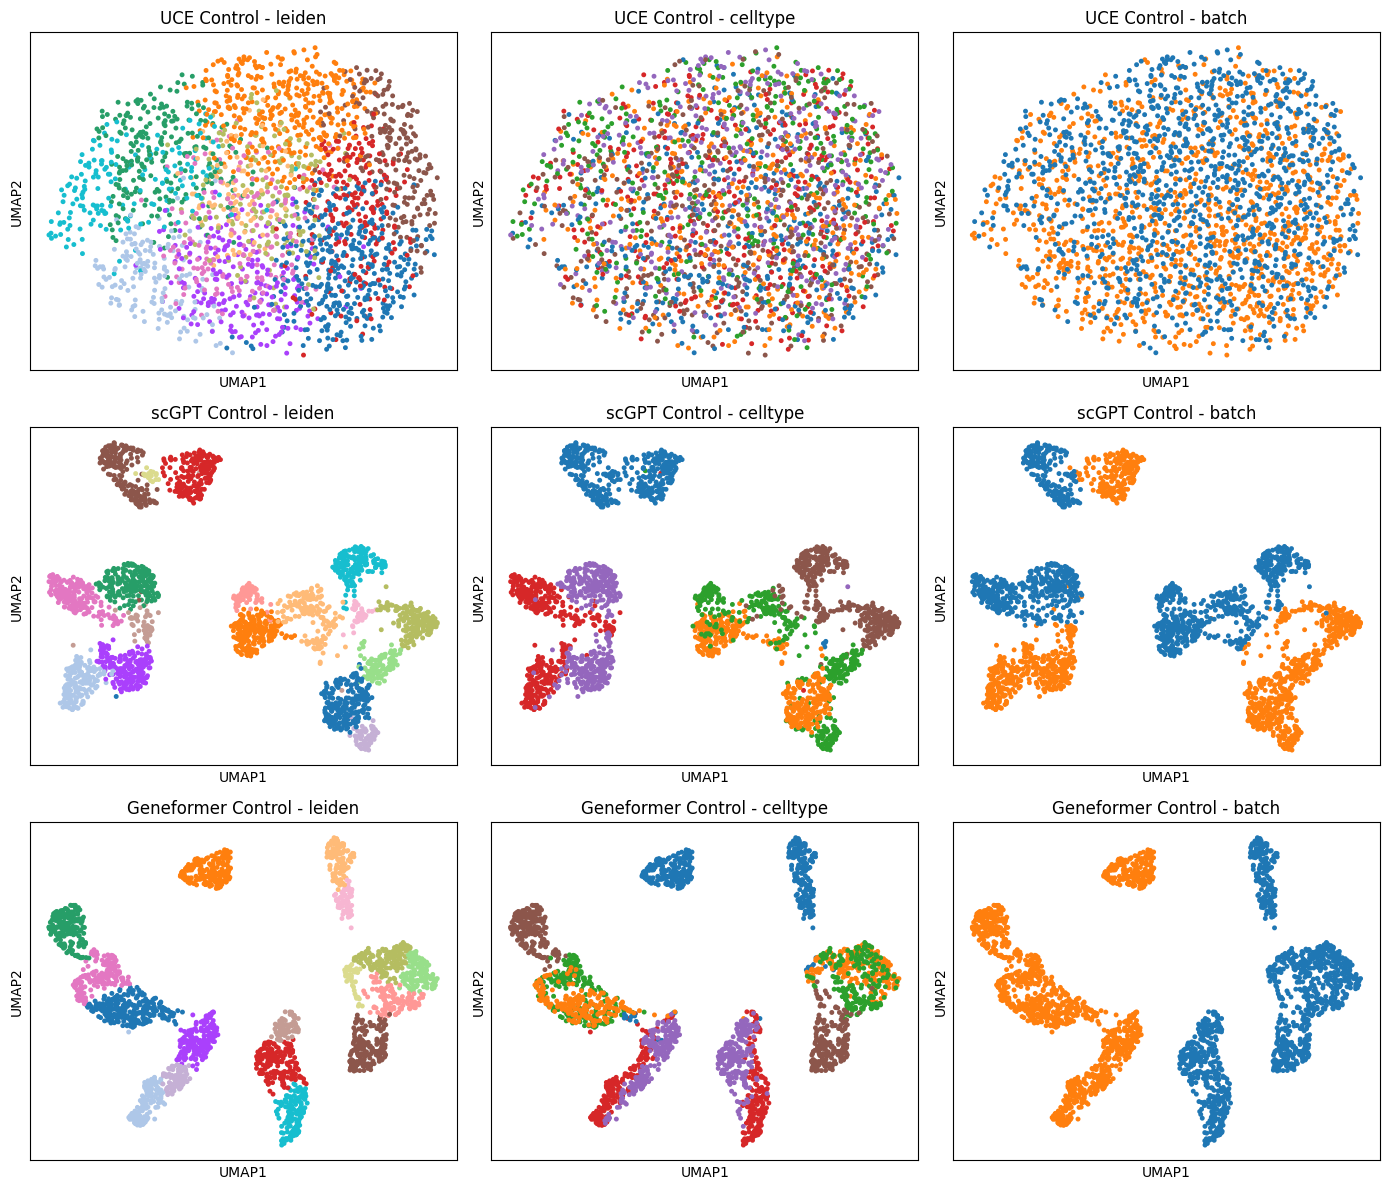

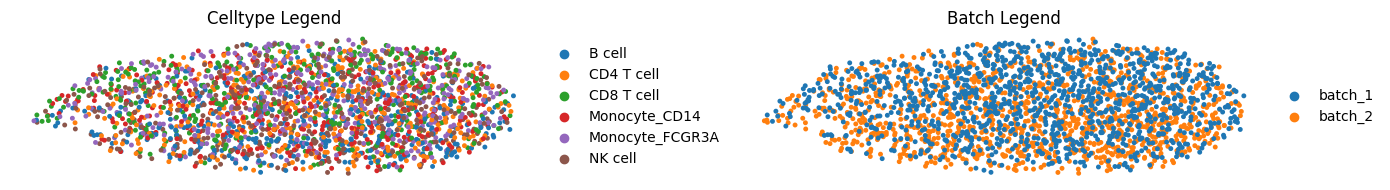

In [ ]:
adatas = [control_adatas_uce[0], control_adatas_scgpt[0], control_adatas_geneformer[0]]
titles = ['UCE Control', 'scGPT Control', 'Geneformer Control']  # Optional labels for rows

# Attributes to color by
attributes = ['leiden', 'celltype', 'batch']

# Create 3x3 plot
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()


# Plot each UMAP
for i, adata in enumerate(adatas):
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_emb_reduced')
    sc.tl.leiden(adata, resolution=1.0)
    sc.tl.umap(adata)  
    for j, attr in enumerate(attributes):
        idx = i * 3 + j
        sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{titles[i]} - {attr}', legend_loc='none')

plt.tight_layout()

# Now create separate figures just for the legends
fig_legend, ax_legend = plt.subplots(1, 2, figsize=(14, 2))

# Celltype legend
sc.pl.umap(
    control_adatas_uce[0],  # or any adata that has the full celltype set
    color='celltype', 
    ax=ax_legend[0], 
    show=False, 
    title='Celltype Legend', 
    legend_loc='right margin', 
    legend_fontsize=10,
    legend_fontoutline=2
)
ax_legend[0].axis('off')  # Hide the UMAP itself

# Batch legend
sc.pl.umap(
    control_adatas_uce[0],  # again, any adata with batch labels
    color='batch', 
    ax=ax_legend[1], 
    show=False, 
    title='Batch Legend', 
    legend_loc='right margin', 
    legend_fontsize=10,
    legend_fontoutline=2
)
ax_legend[1].axis('off')  # Hide the UMAP itself

plt.tight_layout()
plt.savefig("control_umap_grid_new.png", dpi=300, bbox_inches='tight')
plt.savefig("control_umap_legends_new.png", dpi=300, bbox_inches='tight')
plt.show()

## Plotting condusion matrices

17

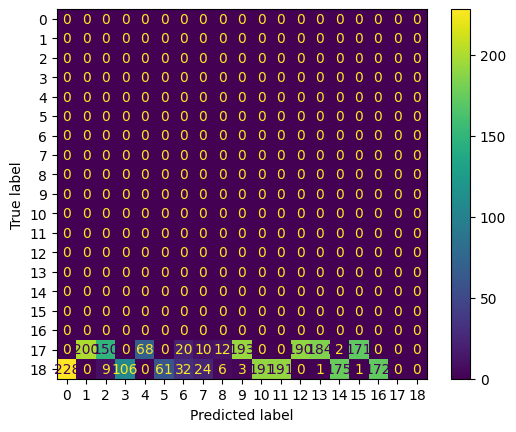

In [ ]:
conf_matrix = get_confusion_matrix(control_adatas_scgpt[0]) # plotting for scGPT control
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot() 

## Computing metrics to quantify performance

In [ ]:
# Loop through and calculate the metrics for each of the adata objects - for UCE, scGPT and Geneformer
control_metrics_uce = []
control_metrics_scgpt = []
control_metrics_geneformer = []

ds_metrics_uce = []
ds_metrics_scgpt = []
ds_metrics_geneformer = []

ablated_metrics_uce = []
ablated_metrics_scgpt = []
ablated_metrics_geneformer = []

# Loop through the control adata objects and calculate the metrics
for adata in control_adatas_uce:
    metrics = get_metrics(adata)
    control_metrics_uce.append(metrics)
    
for adata in control_adatas_scgpt:
    metrics = get_metrics(adata)
    control_metrics_scgpt.append(metrics)
    
for adata in control_adatas_geneformer:
    metrics = get_metrics(adata)
    control_metrics_geneformer.append(metrics)
    
for adata in ds_adatas_uce:
    metrics = get_metrics(adata)
    ds_metrics_uce.append(metrics)
    
for adata in ds_adatas_scgpt:
    metrics = get_metrics(adata)
    ds_metrics_scgpt.append(metrics)
    
for adata in ds_adatas_geneformer:
    metrics = get_metrics(adata)
    ds_metrics_geneformer.append(metrics)
    
for adata in ablated_adatas_uce:
    metrics = get_metrics(adata)
    ablated_metrics_uce.append(metrics)
    
for adata in ablated_adatas_scgpt:
    metrics = get_metrics(adata)
    ablated_metrics_scgpt.append(metrics)
    
for adata in ablated_adatas_geneformer:
    metrics = get_metrics(adata)
    ablated_metrics_geneformer.append(metrics)

# Convert the metrics to dataframes
control_metrics_uce_df = metrics_to_df(control_metrics_uce, integration_method = 'uce', experiment = 'control')
control_metrics_scgpt_df = metrics_to_df(control_metrics_scgpt, integration_method = 'scgpt', experiment = 'control')
control_metrics_geneformer_df = metrics_to_df(control_metrics_geneformer, integration_method = 'geneformer', experiment = 'control')

ds_metrics_uce_df = metrics_to_df(ds_metrics_uce, integration_method = 'uce', experiment = 'downsampled')
ds_metrics_scgpt_df = metrics_to_df(ds_metrics_scgpt, integration_method = 'scgpt', experiment = 'downsampled')
ds_metrics_geneformer_df = metrics_to_df(ds_metrics_geneformer, integration_method = 'geneformer', experiment = 'downsampled')

ablated_metrics_uce_df = metrics_to_df(ablated_metrics_uce, integration_method = 'uce', experiment = 'ablated')
ablated_metrics_scgpt_df = metrics_to_df(ablated_metrics_scgpt, integration_method = 'scgpt', experiment = 'ablated')
ablated_metrics_geneformer_df = metrics_to_df(ablated_metrics_geneformer, integration_method = 'geneformer', experiment = 'ablated')


# Concatenate the dataframes
metrics_df = pd.concat([control_metrics_uce_df, control_metrics_scgpt_df, control_metrics_geneformer_df,
                         ds_metrics_uce_df, ds_metrics_scgpt_df, ds_metrics_geneformer_df,
                         ablated_metrics_uce_df, ablated_metrics_scgpt_df, ablated_metrics_geneformer_df], axis=0)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/var/folders/_5/5fls6c092nd2tmhs4rydngz00000gn/T/ipykernel_1235/4152577842.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0) # originally 1.0


## Plotting Boxplots

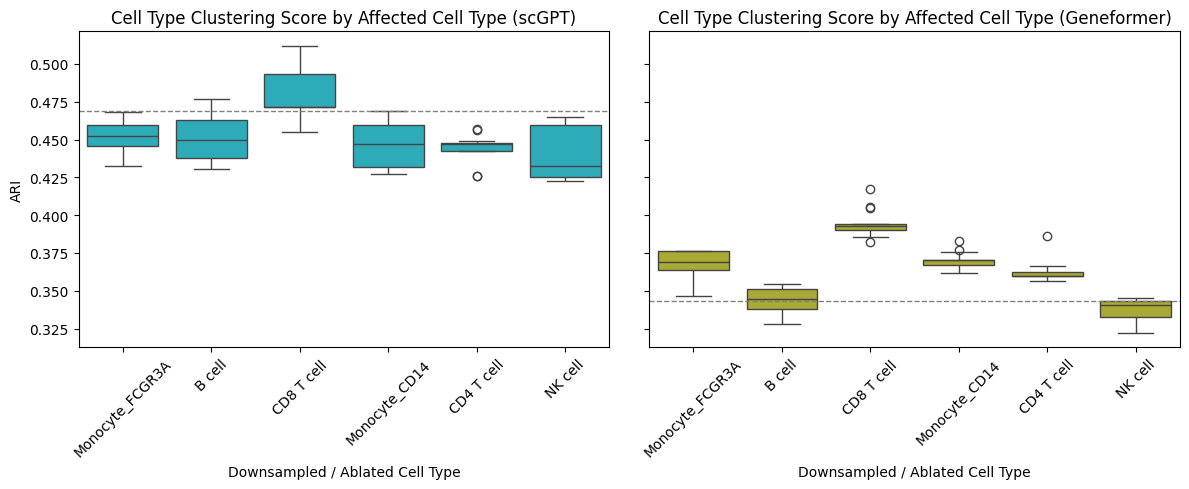

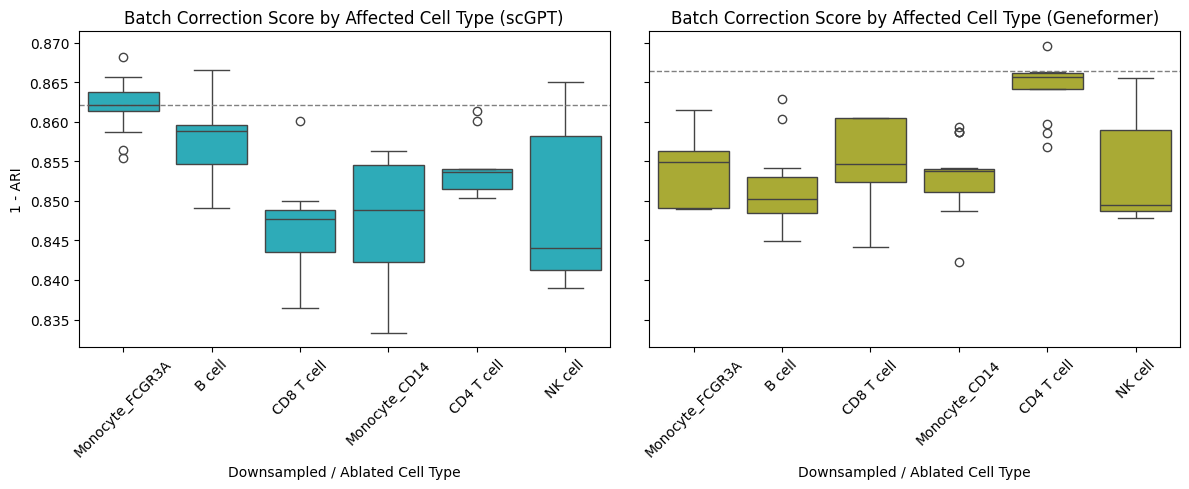

/var/folders/_5/5fls6c092nd2tmhs4rydngz00000gn/T/ipykernel_1235/178576157.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metrics_df_filtered['method_exp'] = metrics_df_filtered['integration_method'] + '_' + metrics_df_filtered['experiment_type']


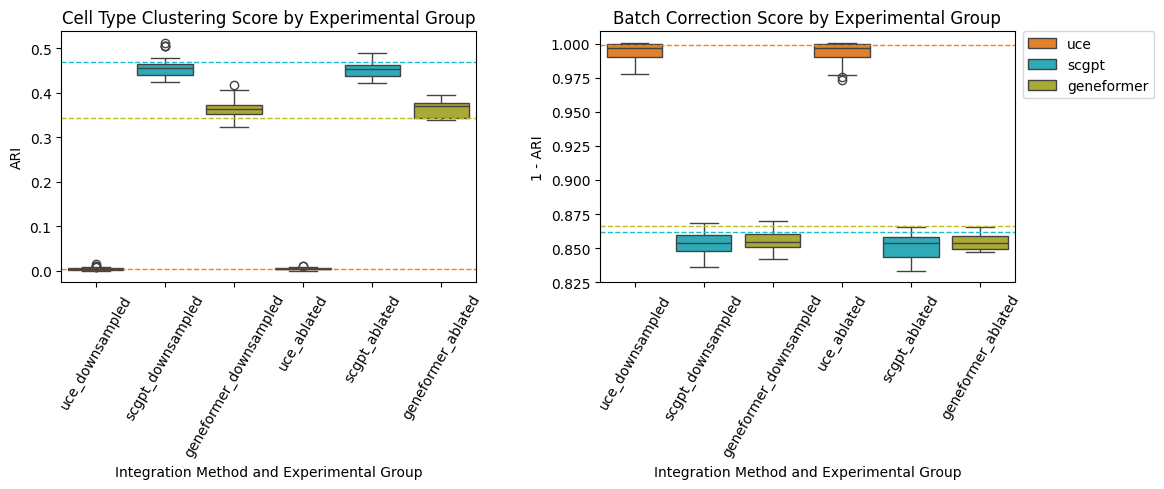

In [ ]:
# Separate metrics_df based on integration method
uce_metrics_df = metrics_df[metrics_df['integration_method'] == 'uce']
scgpt_metrics_df = metrics_df[metrics_df['integration_method'] == 'scgpt']
geneformer_metrics_df = metrics_df[metrics_df['integration_method'] == 'geneformer']

# Filter out 'NA' for plotting
scgpt_filtered = scgpt_metrics_df[scgpt_metrics_df['reduced_celltype'] != 'NA']
geneformer_filtered = geneformer_metrics_df[geneformer_metrics_df['reduced_celltype'] != 'NA']

############################# plotting ARI for cell type clustering

# Get NA medians
na_median_scgpt_ct = scgpt_metrics_df[scgpt_metrics_df['reduced_celltype'] == 'NA']['ari_celltype'].median()
na_median_geneformer_ct = geneformer_metrics_df[geneformer_metrics_df['reduced_celltype'] == 'NA']['ari_celltype'].median()
# for later
na_median_uce_ct = uce_metrics_df[uce_metrics_df['reduced_celltype'] == 'NA']['ari_celltype'].median()


# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) 

# Left plot
sns.boxplot(data=scgpt_filtered, x='reduced_celltype', y='ari_celltype', ax=axes[0], color='tab:cyan')
axes[0].set_title('Cell Type Clustering Score by Affected Cell Type (scGPT)')
axes[0].set_xlabel('Downsampled / Ablated Cell Type')
axes[0].set_ylabel('ARI')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(na_median_scgpt_ct, color='gray', linestyle='--', linewidth=1, label='NA Median')


# Right plot
sns.boxplot(data=geneformer_filtered, x='reduced_celltype', y='ari_celltype', ax=axes[1], color='tab:olive')
axes[1].set_title('Cell Type Clustering Score by Affected Cell Type (Geneformer)')
axes[1].set_xlabel('Downsampled / Ablated Cell Type')
axes[1].set_ylabel('')  # Don't repeat ylabel on second plot
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(na_median_geneformer_ct, color='gray', linestyle='--', linewidth=1, label='NA Median')


plt.tight_layout()
plt.subplots_adjust(wspace=0.075)
plt.savefig("affected_celltype_ct_ari.png", dpi=300)
plt.show()

############################# plotting 1 - ARI for batch clustering

na_median_scgpt_batch = scgpt_metrics_df[scgpt_metrics_df['reduced_celltype'] == 'NA']['ari_batch'].median()
na_median_geneformer_batch = geneformer_metrics_df[geneformer_metrics_df['reduced_celltype'] == 'NA']['ari_batch'].median()
# for later
na_median_uce_batch = uce_metrics_df[uce_metrics_df['reduced_celltype'] == 'NA']['ari_batch'].median()

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) 

# Left plot
sns.boxplot(data=scgpt_filtered, x='reduced_celltype', y='ari_batch', ax=axes[0], color='tab:cyan')
axes[0].set_title('Batch Correction Score by Affected Cell Type (scGPT)')
axes[0].set_xlabel('Downsampled / Ablated Cell Type')
axes[0].set_ylabel('1 - ARI')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(na_median_scgpt_batch, color='gray', linestyle='--', linewidth=1, label='NA Median')


# Right plot
sns.boxplot(data=geneformer_filtered, x='reduced_celltype', y='ari_batch', ax=axes[1], color='tab:olive')
axes[1].set_title('Batch Correction Score by Affected Cell Type (Geneformer)')
axes[1].set_xlabel('Downsampled / Ablated Cell Type')
axes[1].set_ylabel('')  # Don't repeat ylabel on second plot
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(na_median_geneformer_batch, color='gray', linestyle='--', linewidth=1, label='NA Median')


plt.tight_layout()
plt.subplots_adjust(wspace=0.075)
plt.savefig("affected_celltype_batch_ari.png", dpi=300)
plt.show()

############################# ari vs experimental group for each model
metrics_df_filtered = metrics_df[metrics_df['reduced_celltype'] != 'NA']
metrics_df_filtered['method_exp'] = metrics_df_filtered['integration_method'] + '_' + metrics_df_filtered['experiment_type']



# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # separate y axes 

# Left plot
sns.boxplot(data=metrics_df_filtered, x='method_exp', y='ari_celltype', ax=axes[0], hue='integration_method', palette=['tab:orange', 'tab:cyan', 'tab:olive'])
axes[0].set_title('Cell Type Clustering Score by Experimental Group')
axes[0].set_xlabel('Integration Method and Experimental Group')
axes[0].set_ylabel('ARI')
axes[0].tick_params(axis='x', rotation=60)
axes[0].axhline(na_median_uce_ct, color='tab:orange', linestyle='--', linewidth=1)
axes[0].axhline(na_median_scgpt_ct, color='tab:cyan', linestyle='--', linewidth=1)
axes[0].axhline(na_median_geneformer_ct, color='tab:olive', linestyle='--', linewidth=1)
axes[0].get_legend().remove()


# Right plot
sns.boxplot(data=metrics_df_filtered, x='method_exp', y='ari_batch', ax=axes[1], hue='integration_method', palette=['tab:orange', 'tab:cyan', 'tab:olive'])
axes[1].set_title('Batch Correction Score by Experimental Group')
axes[1].set_xlabel('Integration Method and Experimental Group')
axes[1].set_ylabel('1 - ARI')  # Don't repeat ylabel on second plot
axes[1].tick_params(axis='x', rotation=60)
axes[1].axhline(na_median_uce_batch, color='tab:orange', linestyle='--', linewidth=1)
axes[1].axhline(na_median_scgpt_batch, color='tab:cyan', linestyle='--', linewidth=1)
axes[1].axhline(na_median_geneformer_batch, color='tab:olive', linestyle='--', linewidth=1)
axes[1].legend(title='Integration Method',
               bbox_to_anchor=(1.05, 1),  # Move right of the plot
               loc='upper left',
               borderaxespad=0)


plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.savefig("exp_group_all.png", dpi=300)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()